# 📊 Análise de Procrastinação
**Fonte dos dados:** `procrastination_clean.csv` (survey com 106 respondentes) + `procrastinacao_pesquisas.xlsx` (indicadores de literatura científica)

---

**Descrição geral dos gráficos:**
- **Gráfico 1** — Apresenta as principais causas da procrastinação segundo a literatura científica, rankeadas por percentual estimado de ocorrência. Mostra que distração digital e sobrecarga lideram o ranking.
- **Gráfico 2** — Apresenta a variação do score médio de procrastinação por faixa etária dos respondentes do survey. Revela que jovens entre 18 e 24 anos têm escores significativamente mais altos do que adultos mais velhos.
- **Gráfico 3** — Apresenta como condições de saúde mental (TDAH, depressão e ansiedade) impactam o score de procrastinação. Evidencia que pessoas com TDAH e depressão têm escores substancialmente maiores.
- **Gráfico 4** — Apresenta quais tarefas do processo criativo/acadêmico são mais procrastinadas, medindo a frequência alta de adiamento por tipo de atividade. Mostra que revisão de literatura e escrita de relatório são as mais evitadas.
- **Gráfico 5** — Apresenta os comportamentos de fuga mais comuns que as pessoas adotam ao procrastinar. Evidencia que praticamente todos os respondentes recorrem a algum comportamento substituto.
- **Gráfico 6** — Apresenta o impacto da procrastinação em diferentes áreas da vida (acadêmica, profissional e financeira) usando indicadores percentuais da literatura científica. Consolida a narrativa de que a procrastinação afeta múltiplas dimensões da vida.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de estilo
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE_MAIN  = '#4C6EF5'   # azul principal
PALETTE_ACCENT = '#F76707'  # laranja destaque
PALETTE_NEG   = '#E03131'   # vermelho para valores negativos/críticos
PALETTE_SEQ   = 'Blues_d'   # sequencial para barras

# ── Carregamento dos dados ──────────────────────────────────────────────────
df_survey = pd.read_csv('procrastination_clean.csv')
df_causas    = pd.read_excel('procrastinacao_pesquisas.xlsx', sheet_name='fato_causas_rankeadas',   header=1)
df_indicadores = pd.read_excel('procrastinacao_pesquisas.xlsx', sheet_name='fato_indicadores',       header=1)

print(f'Survey: {df_survey.shape[0]} respondentes, {df_survey.shape[1]} variáveis')
print(f'Indicadores científicos: {df_indicadores.shape[0]} linhas')

Survey: 106 respondentes, 38 variáveis
Indicadores científicos: 96 linhas


---
## Gráfico 1 — Principais causas da procrastinação (literatura científica)
**O que representa:** Ranking das causas mais frequentes da procrastinação segundo estudos científicos, com percentual estimado de ocorrência em cada causa. A distração por ambiente digital lidera (48%), seguida de sobrecarga e cansaço. O dado permite mostrar que a procrastinação não é preguiça simples — tem múltiplos gatilhos psicológicos e ambientais.

**Fonte:** `fato_causas_rankeadas` do arquivo xlsx.

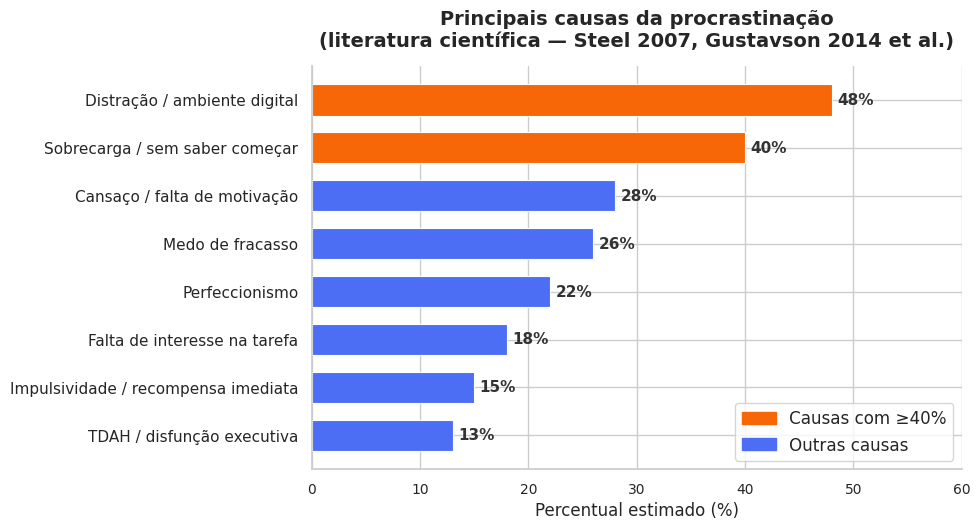

In [ ]:
# ── Gráfico 1: Causas rankeadas ────────────────────────────────────────────
df_c = df_causas.sort_values('percentual_estimado', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))

cores = [PALETTE_ACCENT if x >= 40 else PALETTE_MAIN for x in df_c['percentual_estimado']]

bars = ax.barh(
    df_c['causa'],
    df_c['percentual_estimado'],
    color=cores,
    edgecolor='white',
    linewidth=0.8,
    height=0.65
)

for bar, val in zip(bars, df_c['percentual_estimado']):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f'{val}%', va='center', ha='left', fontsize=11, fontweight='bold',
        color='#333333'
    )

ax.set_xlabel('Percentual estimado (%)', fontsize=12)
ax.set_title(
    'Principais causas da procrastinação\n(literatura científica — Steel 2007, Gustavson 2014 et al.)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlim(0, 60)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

destaque = mpatches.Patch(color=PALETTE_ACCENT, label='Causas com ≥40%')
outros   = mpatches.Patch(color=PALETTE_MAIN,   label='Outras causas')
ax.legend(handles=[destaque, outros], loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('grafico1_causas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Gráfico 2 — Score médio de procrastinação por faixa etária
**O que representa:** A média do score de procrastinação (0–66 pts) calculada para cada faixa etária dos respondentes do survey. Confirma o padrão da literatura: jovens de 18–24 anos têm score ~49, enquanto adultos acima de 36 anos ficam abaixo de 38. Útil para mostrar que a procrastinação tende a diminuir com a maturidade.

**Fonte:** `procrastination_clean.csv` — colunas `faixa_etaria` e `score_procrastinacao`.

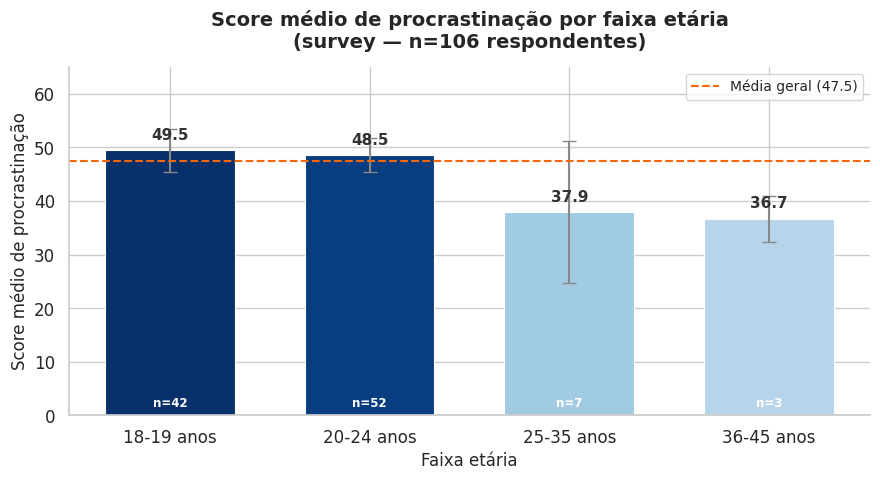

In [ ]:
# ── Gráfico 2: Score por faixa etária ─────────────────────────────────────
ordem_faixa = ['18-19 anos', '20-24 anos', '25-35 anos', '36-45 anos', '46-55 anos', '56-65 anos']
df_idade = (
    df_survey.groupby('faixa_etaria')['score_procrastinacao']
    .agg(['mean', 'sem', 'count'])
    .reindex(ordem_faixa)
    .dropna()
    .reset_index()
)
df_idade.columns = ['faixa_etaria', 'media', 'sem', 'n']

fig, ax = plt.subplots(figsize=(9, 5))

# Gradiente de cores: maior score = cor mais intensa
norm = plt.Normalize(df_idade['media'].min(), df_idade['media'].max())
cmap = plt.cm.get_cmap('Blues')
cores = [cmap(norm(v) * 0.7 + 0.3) for v in df_idade['media']]

bars = ax.bar(
    df_idade['faixa_etaria'], df_idade['media'],
    color=cores, edgecolor='white', linewidth=0.8, width=0.65,
    yerr=df_idade['sem'] * 1.96,
    capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': '#888888'}
)

for bar, row in zip(bars, df_idade.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
        f'{row.media:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333'
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, 1,
        f'n={row.n}', ha='center', va='bottom', fontsize=8.5, color='white', fontweight='bold'
    )

ax.set_xlabel('Faixa etária', fontsize=12)
ax.set_ylabel('Score médio de procrastinação', fontsize=12)
ax.set_title(
    'Score médio de procrastinação por faixa etária\n(survey — n=106 respondentes)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_ylim(0, 65)
ax.axhline(df_survey['score_procrastinacao'].mean(), color=PALETTE_ACCENT,
           linestyle='--', linewidth=1.5, label=f'Média geral ({df_survey["score_procrastinacao"].mean():.1f})')
ax.legend(fontsize=10, framealpha=0.8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico2_faixa_etaria.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Gráfico 3 — Condições de saúde mental e score de procrastinação
**O que representa:** Comparação do score médio de procrastinação entre quem tem e quem não tem TDAH, depressão e ansiedade. Evidencia que saúde mental e procrastinação são fortemente conectadas: pessoas com TDAH têm score ~9 pts maior que a média. Suporta a conclusão de que procrastinação é um sintoma multifatorial.

**Fonte:** `procrastination_clean.csv` — colunas `tdah`, `depressao`, `ansiedade` + `score_procrastinacao`.

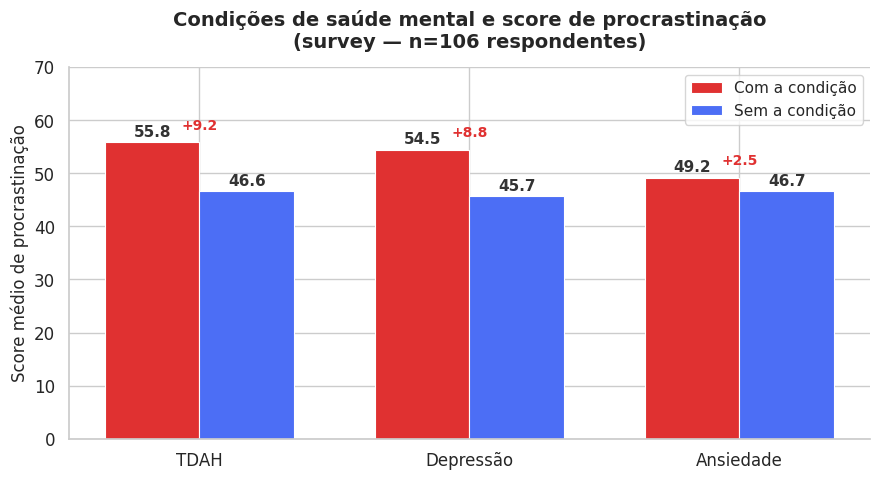

In [ ]:
# ── Gráfico 3: Condições de saúde mental vs score ─────────────────────────
condicoes = {'TDAH': 'tdah', 'Depressão': 'depressao', 'Ansiedade': 'ansiedade'}

rows = []
for label, col in condicoes.items():
    for grupo in ['Sim', 'Não']:
        subset = df_survey[df_survey[col] == grupo]['score_procrastinacao']
        rows.append({'Condição': label, 'Grupo': grupo,
                     'média': subset.mean(), 'n': len(subset)})
df_saude = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(condicoes))
width = 0.35

df_sim = df_saude[df_saude['Grupo'] == 'Sim'].reset_index(drop=True)
df_nao = df_saude[df_saude['Grupo'] == 'Não'].reset_index(drop=True)

bars_sim = ax.bar(x - width/2, df_sim['média'], width, label='Com a condição',
                  color=PALETTE_NEG, edgecolor='white', linewidth=0.8)
bars_nao = ax.bar(x + width/2, df_nao['média'], width, label='Sem a condição',
                  color=PALETTE_MAIN, edgecolor='white', linewidth=0.8)

for bars in [bars_sim, bars_nao]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333'
        )

# Diferença entre os grupos
for i, (_, row_s) in enumerate(df_sim.iterrows()):
    row_n = df_nao.iloc[i]
    diff  = row_s['média'] - row_n['média']
    ax.annotate(
        f'+{diff:.1f}', xy=(x[i], max(row_s['média'], row_n['média']) + 2.5),
        ha='center', fontsize=10, color=PALETTE_NEG, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(list(condicoes.keys()), fontsize=12)
ax.set_ylabel('Score médio de procrastinação', fontsize=12)
ax.set_title(
    'Condições de saúde mental e score de procrastinação\n(survey — n=106 respondentes)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_ylim(0, 70)
ax.legend(fontsize=11, framealpha=0.8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico3_saude_mental.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Gráfico 4 — Tarefas mais procrastinadas no processo criativo/acadêmico
**O que representa:** Quantidade de respondentes que declaram alta frequência de adiamento (diariamente ou várias vezes por semana) para cada tipo de tarefa. Revisão de literatura e escrita de relatório são as mais evitadas, sugerindo que tarefas de produção textual são especialmente difíceis de iniciar.

**Fonte:** `procrastination_pt.csv` — colunas `tarefa_*`.

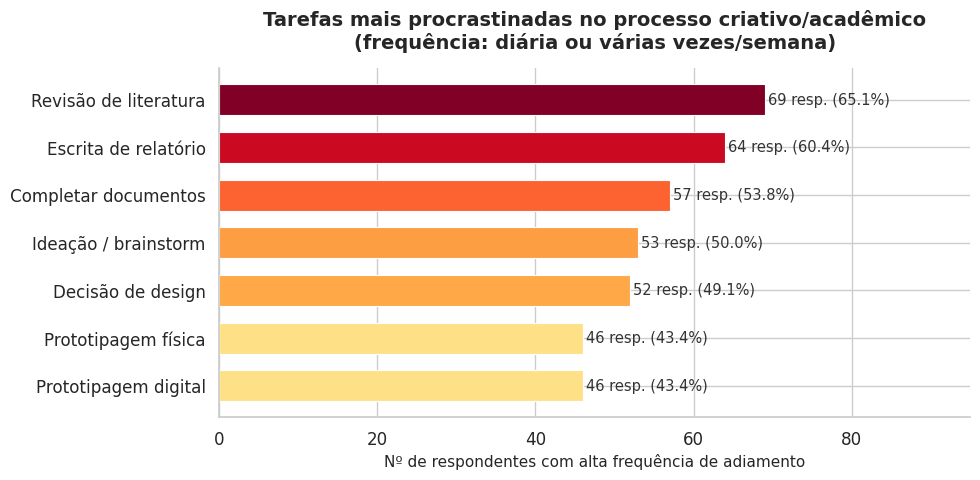

In [ ]:
# ── Gráfico 4: Tarefas mais procrastinadas ────────────────────────────────
tarefas_cols = [c for c in df_survey.columns if c.startswith('tarefa_')]
freq_alta    = ['Mais de uma vez por dia', 'Uma vez por dia', 'Mais de uma vez por semana']

labels_tarefa = {
    'tarefa_revisao_literatura':  'Revisão de literatura',
    'tarefa_ideacao':             'Ideação / brainstorm',
    'tarefa_decisao_design':      'Decisão de design',
    'tarefa_prototipagem_digital':'Prototipagem digital',
    'tarefa_prototipagem_fisica': 'Prototipagem física',
    'tarefa_escrita_relatorio':   'Escrita de relatório',
    'tarefa_completar_documentos':'Completar documentos',
}

df_tarefas = pd.DataFrame({
    'tarefa': [labels_tarefa[c] for c in tarefas_cols],
    'count':  [df_survey[c].isin(freq_alta).sum() for c in tarefas_cols],
    'pct':    [round(df_survey[c].isin(freq_alta).mean() * 100, 1) for c in tarefas_cols],
}).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

norm  = plt.Normalize(df_tarefas['count'].min(), df_tarefas['count'].max())
cores = [plt.cm.get_cmap('YlOrRd')(norm(v) * 0.8 + 0.2) for v in df_tarefas['count']]

bars = ax.barh(df_tarefas['tarefa'], df_tarefas['count'],
               color=cores, edgecolor='white', linewidth=0.8, height=0.65)

for bar, row in zip(bars, df_tarefas.itertuples()):
    ax.text(
        bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
        f'{row.count} resp. ({row.pct}%)',
        va='center', ha='left', fontsize=10.5, color='#333'
    )

ax.set_xlabel('Nº de respondentes com alta frequência de adiamento', fontsize=11)
ax.set_title(
    'Tarefas mais procrastinadas no processo criativo/acadêmico\n(frequência: diária ou várias vezes/semana)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlim(0, 95)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico4_tarefas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Gráfico 5 — Comportamentos de fuga mais comuns
**O que representa:** Mostra para quais atividades as pessoas "fogem" quando estão procrastinando. Quase todos os respondentes (97%+) recorrem a algum comportamento substituto — conversar com amigos, comer, assistir TV e fazer outra tarefa menos importante lideram. Reforça que procrastinação é um comportamento ativo de evitação, não passividade.

**Fonte:** `procrastination_clean.csv` — colunas `fuga_*`.

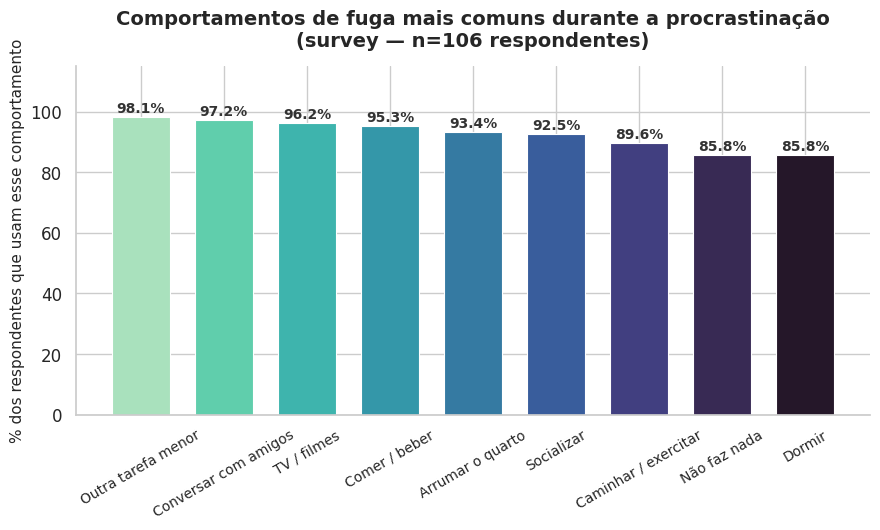

In [ ]:
# ── Gráfico 5: Comportamentos de fuga ─────────────────────────────────────
fugas_cols = [c for c in df_survey.columns if c.startswith('fuga_')]
labels_fuga = {
    'fuga_nao_faz_nada':                  'Não faz nada',
    'fuga_dormir':                         'Dormir',
    'fuga_tv_filmes':                      'TV / filmes',
    'fuga_comer_beber':                    'Comer / beber',
    'fuga_conversar_amigos':               'Conversar com amigos',
    'fuga_socializar':                     'Socializar',
    'fuga_caminhar_exercitar':             'Caminhar / exercitar',
    'fuga_arrumar_quarto':                 'Arrumar o quarto',
    'fuga_outra_tarefa_menos_importante':  'Outra tarefa menor',
}

df_fugas = pd.DataFrame({
    'fuga': [labels_fuga[c] for c in fugas_cols],
    'pct':  [round((df_survey[c] != 'Nunca').mean() * 100, 1) for c in fugas_cols],
}).sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))

palette = sns.color_palette('mako_r', len(df_fugas))
bars = ax.bar(df_fugas['fuga'], df_fugas['pct'],
              color=palette, edgecolor='white', linewidth=0.8, width=0.7)

for bar, val in zip(bars, df_fugas['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
        f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333'
    )

ax.set_ylabel('% dos respondentes que usam esse comportamento', fontsize=11)
ax.set_title(
    'Comportamentos de fuga mais comuns durante a procrastinação\n(survey — n=106 respondentes)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_ylim(0, 115)
ax.tick_params(axis='x', labelrotation=30, labelsize=10)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico5_fugas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Gráfico 6 — Impacto da procrastinação por área de vida
**O que representa:** Consolida os principais indicadores percentuais da literatura científica sobre o impacto da procrastinação nas áreas acadêmica, profissional e financeira. É o gráfico de fechamento — mostra que a procrastinação não é um problema isolado, mas afeta múltiplas dimensões da vida de forma mensurável.

**Fonte:** `fato_indicadores` do arquivo xlsx — categorias Impacto Acadêmico, Impacto Profissional e Impacto Financeiro/Salarial.

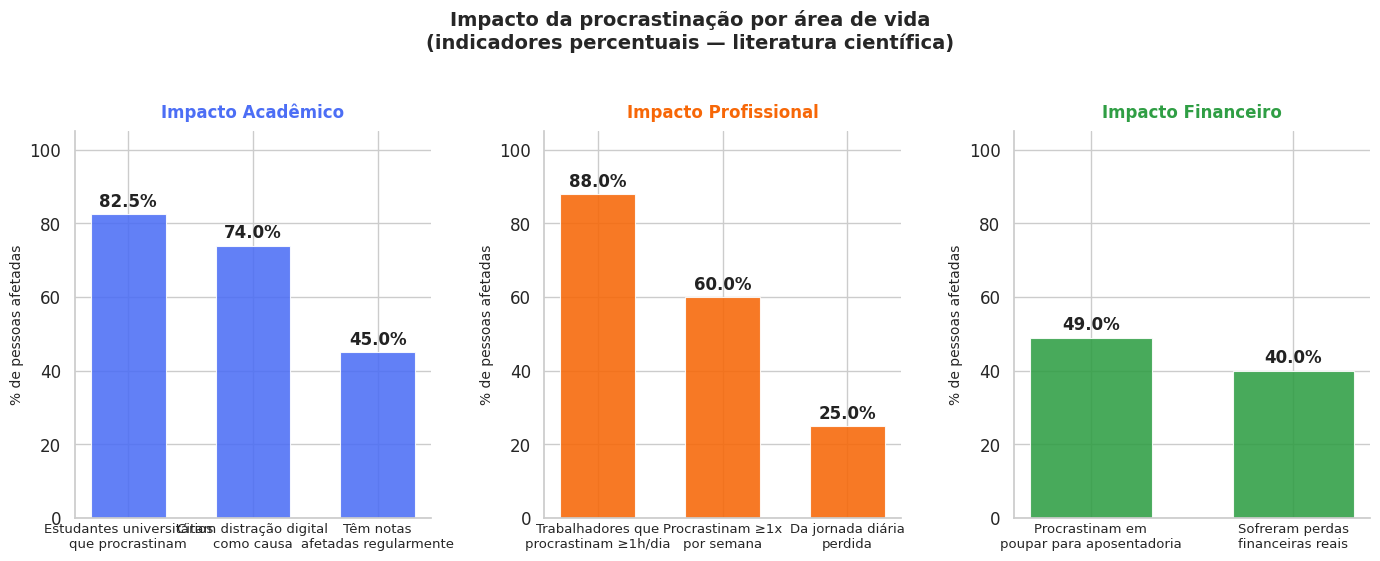

In [ ]:
# ── Gráfico 6: Impacto por área de vida ───────────────────────────────────
cats_impacto = ['Impacto Acadêmico', 'Impacto Profissional', 'Impacto Financeiro/Salarial']
df_imp = df_indicadores[
    df_indicadores['categoria'].isin(cats_impacto) &
    (df_indicadores['unidade'] == '%') &
    (df_indicadores['valor_numerico'] > 0)
].copy()

# Selecionar os indicadores mais representativos de cada categoria
destaques = {
    'Impacto Acadêmico': [
        (82.5, 'Estudantes universitários\nque procrastinam'),
        (74.0, 'Citam distração digital\ncomo causa'),
        (45.0, 'Têm notas\nafetadas regularmente'),
    ],
    'Impacto Profissional': [
        (88.0, 'Trabalhadores que\nprocrastinam ≥1h/dia'),
        (60.0, 'Procrastinam ≥1x\npor semana'),
        (25.0, 'Da jornada diária\nperdida'),
    ],
    'Impacto Financeiro': [
        (49.0, 'Procrastinam em\npoupar para aposentadoria'),
        (40.0, 'Sofreram perdas\nfinanceiras reais'),
    ],
}

cores_area = {
    'Impacto Acadêmico':   '#4C6EF5',
    'Impacto Profissional': '#F76707',
    'Impacto Financeiro':  '#2F9E44',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=False)
fig.suptitle(
    'Impacto da procrastinação por área de vida\n(indicadores percentuais — literatura científica)',
    fontsize=14, fontweight='bold', y=1.02
)

for ax, (area, itens) in zip(axes, destaques.items()):
    labels = [it[1] for it in itens]
    valores = [it[0] for it in itens]
    cor = cores_area[area]

    bars = ax.bar(range(len(itens)), valores, color=cor, edgecolor='white',
                  linewidth=0.8, width=0.6, alpha=0.88)

    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#222'
        )

    ax.set_xticks(range(len(itens)))
    ax.set_xticklabels(labels, fontsize=9.5, ha='center')
    ax.set_ylim(0, 105)
    ax.set_title(area, fontsize=12, fontweight='bold', color=cor, pad=10)
    ax.set_ylabel('% de pessoas afetadas', fontsize=10)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('grafico6_impacto_areas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusão

Os seis gráficos acima constroem uma narrativa completa:

1. **A procrastinação tem causas bem definidas** — distração digital e sobrecarga lideram (Gráfico 1)
2. **Afeta especialmente os mais jovens** — score despenca com a idade (Gráfico 2)
3. **Está ligada à saúde mental** — TDAH e depressão amplificam o efeito (Gráfico 3)
4. **Certas tarefas são mais vulneráveis** — escrita e revisão são as mais evitadas (Gráfico 4)
5. **É um comportamento ativo de evitação** — quase todos substituem a tarefa por outra atividade (Gráfico 5)
6. **Tem impacto mensurável em múltiplas áreas** — acadêmica, profissional e financeira (Gráfico 6)

> **Conclusão:** A procrastinação não é preguiça — é um padrão comportamental complexo que afeta a maioria das pessoas em diferentes dimensões da vida, com causas psicológicas e ambientais identificáveis.